# StaySure Hotel Cancellation ML
## Milestone 6 — Hyperparameter Tuning and Threshold Optimization

**Business goal:** improve the Milestone 5 random forest without allowing an exhaustive search to consume unnecessary time or overfit the validation period.

This learner-led notebook compares a small, predeclared set of random-forest configurations. Selection uses validation ROC AUC as the primary metric while protecting F1 as a guardrail. It then selects a probability threshold using an explicit business-cost assumption. The chronological test set remains sealed.

### Main outputs

- `models/random_forest_tuned_bundle.joblib` — local model, threshold, and metadata bundle (ignored by Git)
- `reports/milestone_06_tuning_results.csv` — every candidate configuration and validation score
- `reports/milestone_06_model_comparison.csv` — untuned-versus-selected validation metrics
- `reports/milestone_06_threshold_analysis.csv` — threshold trade-offs and cost index
- `reports/milestone_06_selected_policy.csv` — selected configuration, threshold, and generalization gaps


### What you should be able to explain afterward

1. What a hyperparameter is and how it differs from a learned parameter.
2. Why a controlled search can be preferable to a very large grid.
3. Why model selection needs both a primary metric and guardrails.
4. Why the probability threshold is a business decision rather than a universal constant.
5. How false-positive and false-negative costs affect threshold selection.
6. Why the test set must remain sealed throughout tuning.


## 1. Setup


In [1]:
from pathlib import Path
from time import perf_counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
RANDOM_STATE = 42
print("Libraries loaded.")


Libraries loaded.


In [2]:
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
CLEAN_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "hotel_bookings_clean.csv"
PREPROCESSOR_PATH = PROJECT_ROOT / "models" / "preprocessing_pipeline.joblib"
M5_MODEL_PATH = PROJECT_ROOT / "models" / "random_forest_candidate.joblib"
FEATURE_MANIFEST_PATH = PROJECT_ROOT / "reports" / "milestone_03_feature_manifest.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)


Project root: C:\Users\theko\ML_Projects\staysure-hotel-cancellation-ml


## 2. Recreate the established chronological split


In [3]:
required_paths = [
    CLEAN_DATA_PATH, PREPROCESSOR_PATH, M5_MODEL_PATH, FEATURE_MANIFEST_PATH,
]
for required_path in required_paths:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required earlier-milestone artifact not found: {required_path}"
        )

df = pd.read_csv(CLEAN_DATA_PATH)
manifest = pd.read_csv(FEATURE_MANIFEST_PATH)
FEATURE_COLUMNS = manifest["source_feature"].tolist()
TARGET = "is_canceled"

month_number = {month: number for number, month in enumerate([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
], start=1)}
df["arrival_date"] = pd.to_datetime({
    "year": df["arrival_date_year"],
    "month": df["arrival_date_month"].map(month_number),
    "day": df["arrival_date_day_of_month"],
})
df = df.sort_values("arrival_date").reset_index(drop=True)

train_df = df[df["arrival_date"] <= "2017-02-10"].copy()
valid_df = df[
    (df["arrival_date"] > "2017-02-10")
    & (df["arrival_date"] <= "2017-05-21")
].copy()
test_row_count = (df["arrival_date"] > "2017-05-21").sum()

X_train, y_train = train_df[FEATURE_COLUMNS].copy(), train_df[TARGET].copy()
X_valid, y_valid = valid_df[FEATURE_COLUMNS].copy(), valid_df[TARGET].copy()

print("Train:", X_train.shape, f"cancellation rate={y_train.mean():.2%}")
print("Validation:", X_valid.shape, f"cancellation rate={y_valid.mean():.2%}")
print("Test rows still sealed:", test_row_count)


Train: (82937, 27) cancellation rate=36.30%
Validation: (17758, 27) cancellation rate=39.47%
Test rows still sealed: 17869


The test period is counted only to verify the boundary. No test feature matrix, target vector, probability, prediction, or metric is created in this notebook.


## 3. Load preprocessing and the Milestone 5 candidate


In [4]:
preprocessor = joblib.load(PREPROCESSOR_PATH)
m5_candidate = joblib.load(M5_MODEL_PATH)
X_train_ready = preprocessor.transform(X_train)
X_valid_ready = preprocessor.transform(X_valid)

assert X_train_ready.shape[0] == len(y_train)
assert X_valid_ready.shape[0] == len(y_valid)
assert X_train_ready.shape[1] == X_valid_ready.shape[1]
assert m5_candidate.n_features_in_ == X_train_ready.shape[1]
print("Train matrix:", X_train_ready.shape)
print("Validation matrix:", X_valid_ready.shape)
print("Milestone 5 candidate loaded.")


Train matrix: (82937, 522)
Validation matrix: (17758, 522)
Milestone 5 candidate loaded.


## 4. Define consistent model evaluation


### TODO 1 — Complete the metric calculations


In [5]:
def evaluate_predictions(model_name, y_true, y_pred, y_probability):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        # TODO 1: Replace each None with the matching metric call.
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
    }


def evaluate_model(model, model_name, X, y, threshold=0.50):
    probabilities = model.predict_proba(X)[:, 1]
    predictions = (probabilities >= threshold).astype(int)
    return evaluate_predictions(model_name, y, predictions, probabilities)

print("Evaluation helpers defined. Complete TODO 1 before continuing.")


Evaluation helpers defined. Complete TODO 1 before continuing.


<details>
<summary>Hint for TODO 1</summary>

Use `precision_score`, `recall_score`, `f1_score`, and `roc_auc_score`. The first three use class predictions; ROC AUC uses probabilities.
</details>


## 5. Establish the untuned reference


In [6]:
m5_metrics = evaluate_model(
    m5_candidate, "M5 random forest", X_valid_ready, y_valid
)
display(pd.DataFrame([m5_metrics]))


,model,accuracy,precision,recall,f1,roc_auc
0,M5 random forest,0.8107,0.7616,0.7576,0.7596,0.8985


This is the model to beat. A tuning result is not automatically better simply because one metric moves upward; material regression in another important metric can make the change undesirable.


## 6. Define a controlled tuning search


The candidates vary four influential hyperparameters:

- `n_estimators`: number of trees.
- `max_depth`: maximum tree depth; `None` permits growth until other stopping rules apply.
- `min_samples_leaf`: minimum rows in a leaf.
- `max_features`: fraction of transformed features considered at each split.

The list is intentionally small and declared before scoring. This reduces compute cost and limits repeated adaptation to the validation period.


In [7]:
BASELINE_PARAMS = {
    "n_estimators": 100,
    "max_depth": 18,
    "min_samples_leaf": 5,
    "max_features": 0.5,
}

CANDIDATE_CONFIGS = [
    {"candidate_id": "T01", "n_estimators": 80, "max_depth": 15,
     "min_samples_leaf": 10, "max_features": 0.5},
    {"candidate_id": "T02", "n_estimators": 80, "max_depth": 12,
     "min_samples_leaf": 20, "max_features": 0.5},
    {"candidate_id": "T03", "n_estimators": 80, "max_depth": 15,
     "min_samples_leaf": 5, "max_features": 0.3},
    {"candidate_id": "T04", "n_estimators": 80, "max_depth": 18,
     "min_samples_leaf": 10, "max_features": 0.3},
    {"candidate_id": "T05", "n_estimators": 100, "max_depth": None,
     "min_samples_leaf": 10, "max_features": 0.3},
    {"candidate_id": "T06", "n_estimators": 150, "max_depth": None,
     "min_samples_leaf": 10, "max_features": 0.3},
    {"candidate_id": "T07", "n_estimators": 100, "max_depth": None,
     "min_samples_leaf": 5, "max_features": 0.3},
]

config_lookup = {"M5": BASELINE_PARAMS}
config_lookup.update({row["candidate_id"]: {
    key: value for key, value in row.items() if key != "candidate_id"
} for row in CANDIDATE_CONFIGS})

print(f"Prepared {len(CANDIDATE_CONFIGS)} alternatives plus the M5 reference.")


Prepared 7 alternatives plus the M5 reference.


### TODO 2 — Explain why this is not an exhaustive grid


Why is a small, predeclared candidate list appropriate for this milestone? Mention both computation and validation overfitting.

A small, predeclared candidate list keeps computation manageable because each random forest requires substantial training time. It also reduces the risk of validation overfitting, which can occur when too many configurations are repeatedly compared against the same validation data. The goal is to test a focused set of reasonable alternatives rather than select a model that performs well only because of validation-specific noise.

<details>
<summary>Suggested explanation</summary>

A controlled list tests plausible changes with manageable runtime. Trying hundreds of combinations would repeatedly adapt decisions to the same validation period, increasing the risk that the chosen result reflects validation-specific noise rather than durable improvement.
</details>


## 7. Run the tuning candidates


In [8]:
tuning_rows = [{
    "candidate_id": "M5",
    **BASELINE_PARAMS,
    **{key: m5_metrics[key] for key in [
        "accuracy", "precision", "recall", "f1", "roc_auc"
    ]},
    "fit_seconds": 0.0,
}]

for config in CANDIDATE_CONFIGS:
    candidate_id = config["candidate_id"]
    params = {key: value for key, value in config.items() if key != "candidate_id"}
    model = RandomForestClassifier(
        **params,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    started = perf_counter()
    model.fit(X_train_ready, y_train)
    fit_seconds = perf_counter() - started
    metrics = evaluate_model(model, candidate_id, X_valid_ready, y_valid)
    tuning_rows.append({
        "candidate_id": candidate_id,
        **params,
        **{key: metrics[key] for key in [
            "accuracy", "precision", "recall", "f1", "roc_auc"
        ]},
        "fit_seconds": fit_seconds,
    })
    print(f"{candidate_id} complete in {fit_seconds:.1f} seconds.")

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(["roc_auc", "f1"], ascending=False)
    .reset_index(drop=True)
)
display(tuning_results)


T01 complete in 27.2 seconds.
T02 complete in 17.7 seconds.
T03 complete in 18.7 seconds.
T04 complete in 21.8 seconds.
T05 complete in 35.0 seconds.
T06 complete in 53.4 seconds.
T07 complete in 48.6 seconds.


,candidate_id,n_estimators,max_depth,min_samples_leaf,max_features,accuracy,precision,recall,f1,roc_auc,fit_seconds
0,T01,80,15.0000,10,0.5000,0.8124,0.7482,0.7910,0.7690,0.9000,27.2359
1,T06,150,NaN,10,0.3000,0.8134,0.7659,0.7595,0.7627,0.8993,53.4445
2,T07,100,NaN,5,0.3000,0.8156,0.7811,0.7402,0.7601,0.8990,48.5988
3,T05,100,NaN,10,0.3000,0.8106,0.7636,0.7532,0.7584,0.8988,35.0128
4,M5,100,18.0000,5,0.5000,0.8107,0.7616,0.7576,0.7596,0.8985,0.0000
5,T03,80,15.0000,5,0.3000,0.8125,0.7837,0.7249,0.7532,0.8984,18.6815
6,T04,80,18.0000,10,0.3000,0.8133,0.7754,0.7419,0.7583,0.8980,21.8337
7,T02,80,12.0000,20,0.5000,0.8101,0.7742,0.7326,0.7528,0.8959,17.7429


Runtime varies by processor and scikit-learn version. On the development machine this search took roughly two minutes; on the computer used for Milestone 5, approximately four to eight minutes is reasonable.


## 8. Apply a metric-and-guardrail selection policy


StaySure will use validation ROC AUC as the primary selection metric because later operations may choose different thresholds. F1 is a guardrail so probability ranking does not improve at the expense of a material decline at the default threshold.


### TODO 3 — Configure the selection policy


In [9]:
# TODO 3: Use "roc_auc" as the primary metric and permit at most a 0.002
# absolute decline from the M5 F1 score.
PRIMARY_METRIC = "roc_auc"
F1_GUARDRAIL_TOLERANCE = 0.002

if PRIMARY_METRIC is None or F1_GUARDRAIL_TOLERANCE is None:
    print("TODO 3: Set the primary metric and F1 tolerance.")
else:
    baseline_f1 = float(
        tuning_results.loc[tuning_results["candidate_id"] == "M5", "f1"].iloc[0]
    )
    eligible_candidates = tuning_results[
        tuning_results["f1"] >= baseline_f1 - F1_GUARDRAIL_TOLERANCE
    ].copy()
    selected_row = (
        eligible_candidates
        .sort_values([PRIMARY_METRIC, "f1"], ascending=False)
        .iloc[0]
    )
    selected_candidate_id = selected_row["candidate_id"]
    selected_params = config_lookup[selected_candidate_id]
    print("Selected candidate:", selected_candidate_id)
    print("Selected parameters:", selected_params)
    display(eligible_candidates.sort_values(PRIMARY_METRIC, ascending=False))


Selected candidate: T01
Selected parameters: {'n_estimators': 80, 'max_depth': 15, 'min_samples_leaf': 10, 'max_features': 0.5}


,candidate_id,n_estimators,max_depth,min_samples_leaf,max_features,accuracy,precision,recall,f1,roc_auc,fit_seconds
0,T01,80,15.0000,10,0.5000,0.8124,0.7482,0.7910,0.7690,0.9000,27.2359
1,T06,150,NaN,10,0.3000,0.8134,0.7659,0.7595,0.7627,0.8993,53.4445
2,T07,100,NaN,5,0.3000,0.8156,0.7811,0.7402,0.7601,0.8990,48.5988
3,T05,100,NaN,10,0.3000,0.8106,0.7636,0.7532,0.7584,0.8988,35.0128
4,M5,100,18.0000,5,0.5000,0.8107,0.7616,0.7576,0.7596,0.8985,0.0000
6,T04,80,18.0000,10,0.3000,0.8133,0.7754,0.7419,0.7583,0.8980,21.8337


**Interpret:** Why is the F1 guardrail useful even though ROC AUC is the primary metric?

## F1 GUARDRAIL with ROC AUC
The F1 guardrail prevents the selection process from choosing a model that improves threshold-independent ranking performance while significantly weakening classification performance at the default threshold. ROC AUC evaluates performance across all possible thresholds, whereas F1 measures the balance between precision and recall at a specific threshold. Using both ensures that the selected model has strong overall discrimination without sacrificing practical prediction quality.


## 9. Refit and compare the selected configuration


In [10]:
if "selected_params" not in globals():
    print("Complete TODO 3 first.")
else:
    tuned_model = RandomForestClassifier(
        **selected_params,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    tuned_model.fit(X_train_ready, y_train)

    tuned_train_metrics = evaluate_model(
        tuned_model, "Selected tuned forest", X_train_ready, y_train
    )
    tuned_valid_metrics = evaluate_model(
        tuned_model, "Selected tuned forest", X_valid_ready, y_valid
    )

    # TODO 4: Put the M5 and tuned validation dictionaries in this list.
    comparison_rows = [m5_metrics, tuned_valid_metrics]
    if comparison_rows is None:
        print("TODO 4: Add both validation metric dictionaries.")
    else:
        model_comparison = pd.DataFrame(comparison_rows)
        display(model_comparison)


,model,accuracy,precision,recall,f1,roc_auc
0,M5 random forest,0.8107,0.7616,0.7576,0.7596,0.8985
1,Selected tuned forest,0.8124,0.7482,0.7910,0.7690,0.9000


### TODO 4 interpretation

Did tuning produce a meaningful improvement? Discuss ROC AUC, F1, and the size of the differences rather than declaring victory from any positive decimal change.

## TUNING ANALYSIS
Tuning produced a modest improvement rather than a dramatic performance gain. ROC AUC increased from 0.8985 to 0.9000, a difference of only 0.0015, while F1 increased from 0.7596 to 0.7690, a more noticeable gain of 0.0094. Recall improved from 0.7576 to 0.7910, meaning the tuned model identifies more cancellations, but precision decreased from 0.7616 to 0.7482. Overall, the tuned model offers a useful improvement in recall and F1, although the ROC AUC increase is small and the precision tradeoff should be considered.


## 10. Optimize the probability threshold


The default threshold of `0.50` is not a law. For this exercise, assume that a missed cancellation (**false negative**) costs StaySure twice as much as contacting or acting on a booking that ultimately arrives (**false positive**).

This is an explicit modeling assumption, not a measured dollar estimate. A production decision would replace it with finance and operations data.


### TODO 5 — Configure thresholds and the cost assumption


In [11]:
# TODO 5: Use thresholds from 0.30 through 0.70 in 0.05 increments,
# and set a false negative to cost twice a false positive.
THRESHOLDS = np.arange(0.30, 0.71, 0.05)
FALSE_POSITIVE_COST = 1
FALSE_NEGATIVE_COST = 2

if THRESHOLDS is None or FALSE_NEGATIVE_COST is None:
    print("TODO 5: Set the thresholds and false-negative cost.")
else:
    tuned_probabilities = tuned_model.predict_proba(X_valid_ready)[:, 1]
    threshold_rows = []
    for threshold in THRESHOLDS:
        predictions = (tuned_probabilities >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_valid, predictions).ravel()
        threshold_rows.append({
            "threshold": threshold,
            "precision": precision_score(y_valid, predictions, zero_division=0),
            "recall": recall_score(y_valid, predictions, zero_division=0),
            "f1": f1_score(y_valid, predictions, zero_division=0),
            "predicted_cancellation_rate": predictions.mean(),
            "true_negatives": tn,
            "false_positives": fp,
            "false_negatives": fn,
            "true_positives": tp,
            "cost_index": (
                FALSE_POSITIVE_COST * fp + FALSE_NEGATIVE_COST * fn
            ),
        })

    threshold_analysis = pd.DataFrame(threshold_rows)
    display(threshold_analysis)


,threshold,precision,recall,f1,predicted_cancellation_rate,true_negatives,false_positives,false_negatives,true_positives,cost_index
0,0.3000,0.5959,0.9568,0.7344,0.6337,6201,4548,303,6706,5154
1,0.3500,0.6159,0.9377,0.7435,0.6009,6651,4098,437,6572,4972
2,0.4000,0.6476,0.9081,0.7561,0.5534,7286,3463,644,6365,4751
3,0.4500,0.6926,0.8606,0.7675,0.4904,8072,2677,977,6032,4631
4,0.5000,0.7482,0.7910,0.7690,0.4173,8883,1866,1465,5544,4796
5,0.5500,0.7809,0.7206,0.7496,0.3642,9332,1417,1958,5051,5333
6,0.6000,0.8079,0.6793,0.7380,0.3319,9617,1132,2248,4761,5628
7,0.6500,0.8188,0.6485,0.7237,0.3126,9743,1006,2464,4545,5934
8,0.7000,0.8265,0.6179,0.7072,0.2951,9840,909,2678,4331,6265


### Visualize the threshold trade-offs


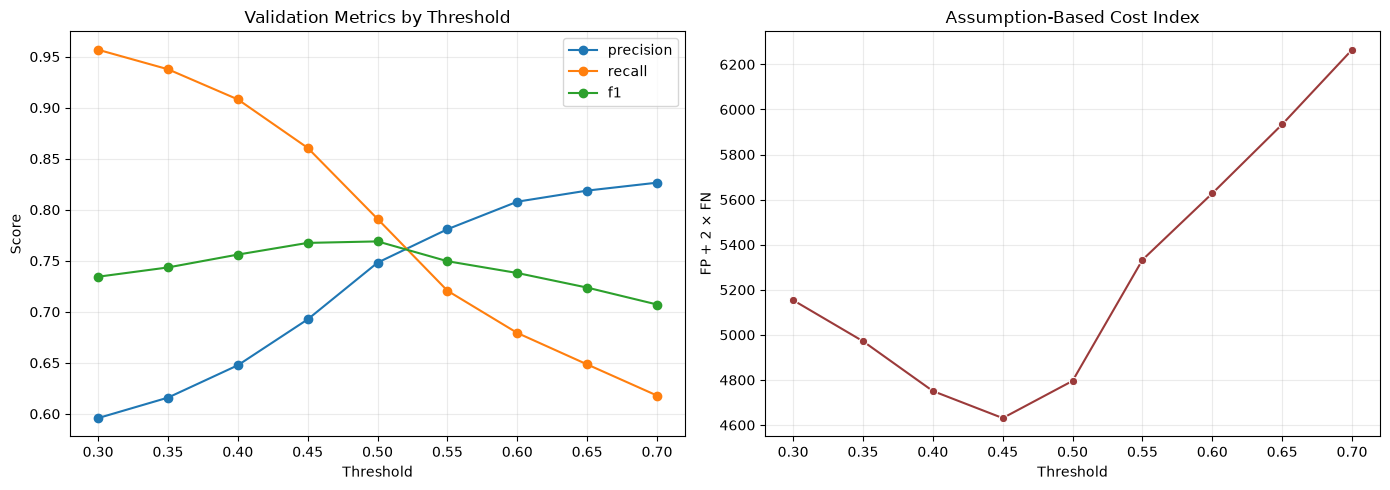

In [12]:
if "threshold_analysis" not in globals():
    print("Complete TODO 5 first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for metric in ["precision", "recall", "f1"]:
        axes[0].plot(
            threshold_analysis["threshold"],
            threshold_analysis[metric],
            marker="o",
            label=metric,
        )
    axes[0].set_title("Validation Metrics by Threshold")
    axes[0].set_xlabel("Threshold")
    axes[0].set_ylabel("Score")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    sns.lineplot(
        data=threshold_analysis,
        x="threshold",
        y="cost_index",
        marker="o",
        ax=axes[1],
        color="#9b3a3a",
    )
    axes[1].set_title("Assumption-Based Cost Index")
    axes[1].set_xlabel("Threshold")
    axes[1].set_ylabel("FP + 2 × FN")
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## 11. Select and document the operating threshold


### TODO 6 — Choose the minimum-cost threshold


In [13]:
if "threshold_analysis" not in globals():
    print("Complete TODO 5 first.")
else:
    # TODO 6: Use idxmin() on cost_index to locate the selected row.
    selected_threshold_index = threshold_analysis["cost_index"].idxmin()

    if selected_threshold_index is None:
        print("TODO 6: Locate the minimum-cost row.")
    else:
        selected_threshold_row = threshold_analysis.loc[selected_threshold_index]
        selected_threshold = float(selected_threshold_row["threshold"])
        print(f"Selected operating threshold: {selected_threshold:.2f}")
        display(selected_threshold_row.to_frame("selected_policy"))


Selected operating threshold: 0.45


,selected_policy
threshold,0.4500
precision,0.6926
recall,0.8606
f1,0.7675
predicted_cancellation_rate,0.4904
true_negatives,"8,072.0000"
false_positives,"2,677.0000"
false_negatives,977.0000
true_positives,"6,032.0000"
cost_index,"4,631.0000"


### TODO 6 interpretation

Explain why the selected threshold is lower than `0.50`. What operational benefit and trade-off does this create?

## MODEL THRESHOLD EXPLANATION
The selected threshold is lower than 0.50 because a false negative is assumed to cost twice as much as a false positive. Lowering the threshold to 0.45 allows the model to identify more likely cancellations, producing a recall of 0.8606 and reducing missed cancellations to 977. The trade-off is that more bookings are flagged, which lowers precision to 0.6926 and increases false positives to 2,677. Operationally, StaySure would catch more cancellations but would also spend more time contacting or acting on guests who ultimately arrive.

<details>
<summary>Suggested interpretation</summary>

Because false negatives are assumed to cost twice as much, the policy favors higher recall and accepts more false positives. The lower threshold catches more real cancellations but also flags more bookings that eventually arrive.
</details>


## 12. Build the selected-policy report


In [14]:
if "selected_threshold" not in globals():
    print("Complete TODO 6 first.")
else:
    selected_policy = pd.DataFrame([{
        "selected_candidate_id": selected_candidate_id,
        **selected_params,
        "primary_metric": PRIMARY_METRIC,
        "f1_guardrail_tolerance": F1_GUARDRAIL_TOLERANCE,
        "selected_threshold": selected_threshold,
        "false_positive_cost": FALSE_POSITIVE_COST,
        "false_negative_cost": FALSE_NEGATIVE_COST,
        "validation_precision": selected_threshold_row["precision"],
        "validation_recall": selected_threshold_row["recall"],
        "validation_f1": selected_threshold_row["f1"],
        "validation_roc_auc": tuned_valid_metrics["roc_auc"],
        "default_threshold_f1_gap": (
            tuned_train_metrics["f1"] - tuned_valid_metrics["f1"]
        ),
        "roc_auc_generalization_gap": (
            tuned_train_metrics["roc_auc"] - tuned_valid_metrics["roc_auc"]
        ),
    }])
    display(selected_policy.T)


,0
selected_candidate_id,T01
n_estimators,80
max_depth,15
min_samples_leaf,10
max_features,0.5000
primary_metric,roc_auc
f1_guardrail_tolerance,0.0020
selected_threshold,0.4500
false_positive_cost,1
false_negative_cost,2


## 13. Save reproducible outputs


### TODO 7 — Save the tuned bundle and reports


In [15]:
required_objects = [
    "tuning_results", "model_comparison", "threshold_analysis",
    "selected_policy", "tuned_model",
]
if any(name not in globals() for name in required_objects):
    print("Complete TODOs 1–6 first.")
else:
    # TODO 7: Replace None with the fitted selected model.
    MODEL_TO_SAVE = tuned_model

    if MODEL_TO_SAVE is None:
        print("TODO 7: Choose the fitted tuned model to save.")
    else:
        model_bundle = {
            "model": MODEL_TO_SAVE,
            "threshold": selected_threshold,
            "feature_columns": FEATURE_COLUMNS,
            "selected_params": selected_params,
            "false_positive_cost": FALSE_POSITIVE_COST,
            "false_negative_cost": FALSE_NEGATIVE_COST,
        }
        joblib.dump(
            model_bundle,
            MODELS_DIR / "random_forest_tuned_bundle.joblib",
        )
        tuning_results.to_csv(
            REPORTS_DIR / "milestone_06_tuning_results.csv", index=False
        )
        model_comparison.to_csv(
            REPORTS_DIR / "milestone_06_model_comparison.csv", index=False
        )
        threshold_analysis.to_csv(
            REPORTS_DIR / "milestone_06_threshold_analysis.csv", index=False
        )
        selected_policy.to_csv(
            REPORTS_DIR / "milestone_06_selected_policy.csv", index=False
        )
        print("Tuned model bundle and four Milestone 6 reports saved.")


Tuned model bundle and four Milestone 6 reports saved.


In [16]:
bundle_path = MODELS_DIR / "random_forest_tuned_bundle.joblib"
report_paths = [
    REPORTS_DIR / "milestone_06_tuning_results.csv",
    REPORTS_DIR / "milestone_06_model_comparison.csv",
    REPORTS_DIR / "milestone_06_threshold_analysis.csv",
    REPORTS_DIR / "milestone_06_selected_policy.csv",
]

if bundle_path.exists() and all(path.exists() for path in report_paths):
    saved_bundle = joblib.load(bundle_path)
    assert "X_test" not in globals() and "y_test" not in globals()
    assert len(tuning_results) == len(CANDIDATE_CONFIGS) + 1
    assert set(model_comparison["model"]) == {
        "M5 random forest", "Selected tuned forest"
    }
    assert selected_threshold in threshold_analysis["threshold"].values
    assert np.isclose(saved_bundle["threshold"], selected_threshold)
    assert saved_bundle["model"].n_features_in_ == X_train_ready.shape[1]
    print("Milestone 6 validation checks passed.")
else:
    print("Complete TODO 7 and save all outputs first.")


Milestone 6 validation checks passed.


## Expected result range

Small software-version differences can change the winning candidate. With the recommended entries, a typical result is:

| Model/policy | Precision | Recall | F1 | ROC AUC |
|---|---:|---:|---:|---:|
| M5 forest at 0.50 | 0.76 | 0.76 | 0.76 | 0.899 |
| Selected tuned forest at 0.50 | 0.78 | 0.75 | 0.76 | 0.900 |
| Selected tuned forest near 0.40 | 0.70 | 0.84 | 0.76 | 0.900 |

The selected threshold should usually be near `0.40` under the assumption that a false negative costs twice a false positive. If results differ substantially, check the split dates, earlier artifacts, candidate settings, and cost formula.


## Interview-ready summary

Complete this after the notebook runs:

> I tuned the Milestone 5 random forest using a small, predeclared candidate set and chronological validation data. I selected ROC AUC as the primary metric while enforcing an F1 guardrail, which prevented a ranking improvement from hiding a material default-threshold decline. I then optimized the operating threshold using an explicit cost assumption that false negatives cost twice as much as false positives. The selected lower threshold increased cancellation recall while accepting more false alerts. I saved the model and threshold together and kept the test set sealed for final evaluation.


## Questions you should be ready to answer

1. What is the difference between a model parameter and a hyperparameter?
2. Why was the candidate search intentionally small?
3. How can repeated tuning overfit a validation set?
4. Why use ROC AUC as the primary metric?
5. What role does the F1 guardrail play?
6. Why is `0.50` not automatically the best threshold?
7. How does increasing the false-negative cost affect the selected threshold?
8. Why save the threshold with the fitted model?
9. Why does a small metric improvement require cautious interpretation?
10. Why is the test set still sealed after tuning?

## Interview Ready Answers
1. Model parameter vs. hyperparameter:
Parameters are learned from training data, such as tree split rules. Hyperparameters are chosen before training, such as max_depth and n_estimators.

2. Why was the candidate search small?
To control computation time and reduce excessive reuse of the validation set.

3. How can repeated tuning overfit validation data?
Repeatedly selecting configurations based on the same validation results can favor validation-specific noise instead of generalizable performance.

4. Why use ROC AUC as the primary metric?
ROC AUC measures how well the model ranks cancellations above non-cancellations across every possible threshold.

5. What does the F1 guardrail do?
It prevents selecting a high-ROC-AUC model that causes an unacceptable decline in the balance between precision and recall.

6. Why isn’t 0.50 automatically best?
The ideal threshold depends on business costs and the desired precision–recall trade-off. Your analysis selected 0.45.

7. What happens when false-negative cost increases?
The preferred threshold generally decreases, increasing recall and reducing missed cancellations while producing more false positives.

8. Why save the threshold with the model?
The model produces probabilities; the saved threshold defines how those probabilities become operational classifications.

9. Why interpret a small improvement cautiously?
Small differences may result from sampling variation and may not persist on new data.

10. Why is the test set still sealed?
It must remain untouched so it can provide an unbiased final evaluation after every model and threshold decision is fixed.


## Milestone 6 completion checklist

- [x] Loaded the Milestone 5 model and earlier preprocessing artifacts
- [x] Recreated the chronological train/validation boundary
- [x] Kept the future test set sealed
- [x] Evaluated the untuned Milestone 5 reference
- [x] Ran the controlled hyperparameter candidates
- [x] Applied ROC AUC selection with an F1 guardrail
- [x] Refit and compared the selected configuration
- [x] Quantified threshold precision-recall trade-offs
- [x] Applied an explicit false-positive/false-negative cost assumption
- [x] Saved the tuned model and threshold together
- [x] Saved four reproducible reports
- [x] Can explain the tuning and threshold decisions in business language
